# Check heuristics

Load benchmark results and compare threading heuristics using helpers from `plot_results.py`.

In [1]:
import pandas as pd
from plot_results import get_all_run_ids, load_cpu_info, load_speedups_for_run

In [2]:
def get_n_threads_limited_32955(n_samples, n_features, n_cpus):
    # heuristics in https://github.com/scikit-learn/scikit-learn/pull/32955
    n_threads = min(
        n_cpus,
        min(
            max(n_samples * n_features // 1_000_000, 1),
            max(n_features // 2, 1),
        ),
    )
    return n_threads

In [3]:
def build_results_df():
    rows = []

    for run_id in get_all_run_ids():
        cpu = load_cpu_info(run_id)
        speedups = load_speedups_for_run(run_id)
        if speedups.empty:
            continue

        selected = speedups[["max_num_threads", "n_samples", "n_features", "fit_speedup", "predict_speedup"]].copy()
        selected = selected.rename(columns={"max_num_threads": "n_threads"})
        selected.insert(0, "run_id", run_id)
        selected.insert(1, "system", cpu.get("system"))
        selected.insert(2, "machine", cpu.get("machine"))
        selected.insert(3, "n_cpus", cpu.get("cpu_logical_cores"))
        rows.append(selected)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=[
        "run_id",
        "system",
        "machine",
        "n_cpus",
        "n_threads",
        "n_samples",
        "n_features",
        "fit_speedup",
        "predict_speedup",
    ])


results_df = build_results_df()
results_df.head()

,run_id,system,machine,n_cpus,n_threads,n_samples,n_features,fit_speedup,predict_speedup
0,20260319_170137,Darwin,arm64,8,1,100,10,1.000000,1.000000
1,20260319_170137,Darwin,arm64,8,2,100,10,0.253505,0.260578
2,20260319_170137,Darwin,arm64,8,4,100,10,0.161689,0.157989
3,20260319_170137,Darwin,arm64,8,8,100,10,0.112090,0.096702
4,20260319_170137,Darwin,arm64,8,1,100,100,1.000000,1.000000


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullLocator


def _build_shape_runs(results_df, get_n_threads_limited, ycol="fit_speedup"):
    shape_runs = (
        results_df[
            ["run_id", "system", "machine", "n_cpus", "n_samples", "n_features"]
        ]
        .drop_duplicates()
        .reset_index(drop=True)
    )
    shape_runs["n_threads"] = shape_runs.apply(
        lambda r: get_n_threads_limited(
            r["n_samples"], r["n_features"], r["n_cpus"]
        ),
        axis=1,
    )

    def _interp_speedup(row, ref):
        sub = ref[
            (ref["run_id"] == row["run_id"])
            & (ref["n_samples"] == row["n_samples"])
            & (ref["n_features"] == row["n_features"])
        ].sort_values("n_threads")
        if sub.empty:
            return np.nan
        xp = sub["n_threads"].to_numpy(dtype=float)
        fp = sub[ycol].to_numpy(dtype=float)
        x = float(row["n_threads"])
        if x <= xp[0]:
            return float(fp[0])
        if x >= xp[-1]:
            return float(fp[-1])
        return float(np.interp(x, xp, fp))

    shape_runs[ycol] = shape_runs.apply(
        lambda r: _interp_speedup(r, results_df),
        axis=1,
    )
    return shape_runs


def plot_fit_speedup_grid(results_df, get_n_threads_limited, ycol="fit_speedup"):
    if ycol not in ("fit_speedup", "predict_speedup"):
        raise ValueError('ycol must be "fit_speedup" or "predict_speedup"')
    ylabel = ycol

    plot_df = results_df.copy()
    shape_runs = _build_shape_runs(plot_df, get_n_threads_limited, ycol=ycol)
    thread_values = sorted(plot_df["n_threads"].unique())

    run_ids = list(plot_df["run_id"].drop_duplicates())
    n_samples_vals = sorted(plot_df["n_samples"].unique())
    n_features_vals = sorted(plot_df["n_features"].unique())
    cmap = plt.colormaps["tab10"]
    nf_color = {nf: cmap(i % 10) for i, nf in enumerate(n_features_vals)}

    fig, axs = plt.subplots(
        len(run_ids),
        len(n_samples_vals),
        figsize=(4 * len(n_samples_vals), 2.5 * len(run_ids)),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    n_rows = len(run_ids)

    for r, run_id in enumerate(run_ids):
        run_df = plot_df[plot_df["run_id"] == run_id]
        meta = run_df[["system", "machine", "n_cpus"]].iloc[0]

        for c, n_samples in enumerate(n_samples_vals):
            ax = axs[r, c]
            sub = run_df[run_df["n_samples"] == n_samples]

            for nf in n_features_vals:
                g = sub[sub["n_features"] == nf].sort_values("n_threads")
                if g.empty:
                    continue
                color = nf_color[nf]
                ax.plot(
                    g["n_threads"],
                    g[ycol],
                    "-",
                    color=color,
                    label=f"n_features={nf}",
                )

                m = shape_runs[
                    (shape_runs["run_id"] == run_id)
                    & (shape_runs["n_samples"] == n_samples)
                    & (shape_runs["n_features"] == nf)
                ]
                if not m.empty:
                    ax.scatter(
                        m["n_threads"].iloc[0],
                        m[ycol].iloc[0],
                        marker="o",
                        s=44,
                        color=color,
                        linewidths=1.2,
                        zorder=5,
                    )

            ax.axhline(1, linestyle="--", color="gray", zorder=0)
            ax.plot(
                thread_values,
                thread_values,
                linestyle="--",
                color="gray",
                zorder=0,
            )
            ax.set(
                xscale="log",
                xticks=thread_values,
                xticklabels=thread_values,
                yscale="log",
                yticks=[0.1, 0.2, 0.5, 1, 2, 5, 10],
                yticklabels=["0.1x", "0.2x", "0.5x", "1x", "2x", "5x", "10x"],
            )
            ax.xaxis.set_minor_locator(NullLocator())

            if r == 0:
                ax.set_title(f"n_samples={n_samples}")
            if c == 0:
                ax.set_ylabel(
                    f"{ylabel}\n{run_id}\n{meta['system']} {meta['machine']} ({meta['n_cpus']} cpus)",
                    fontsize=9,
                )
            if r == n_rows - 1:
                ax.set_xlabel("Number of threads")

    axs[0, 0].legend(fontsize=8, loc="best")
    fig.tight_layout()
    return fig

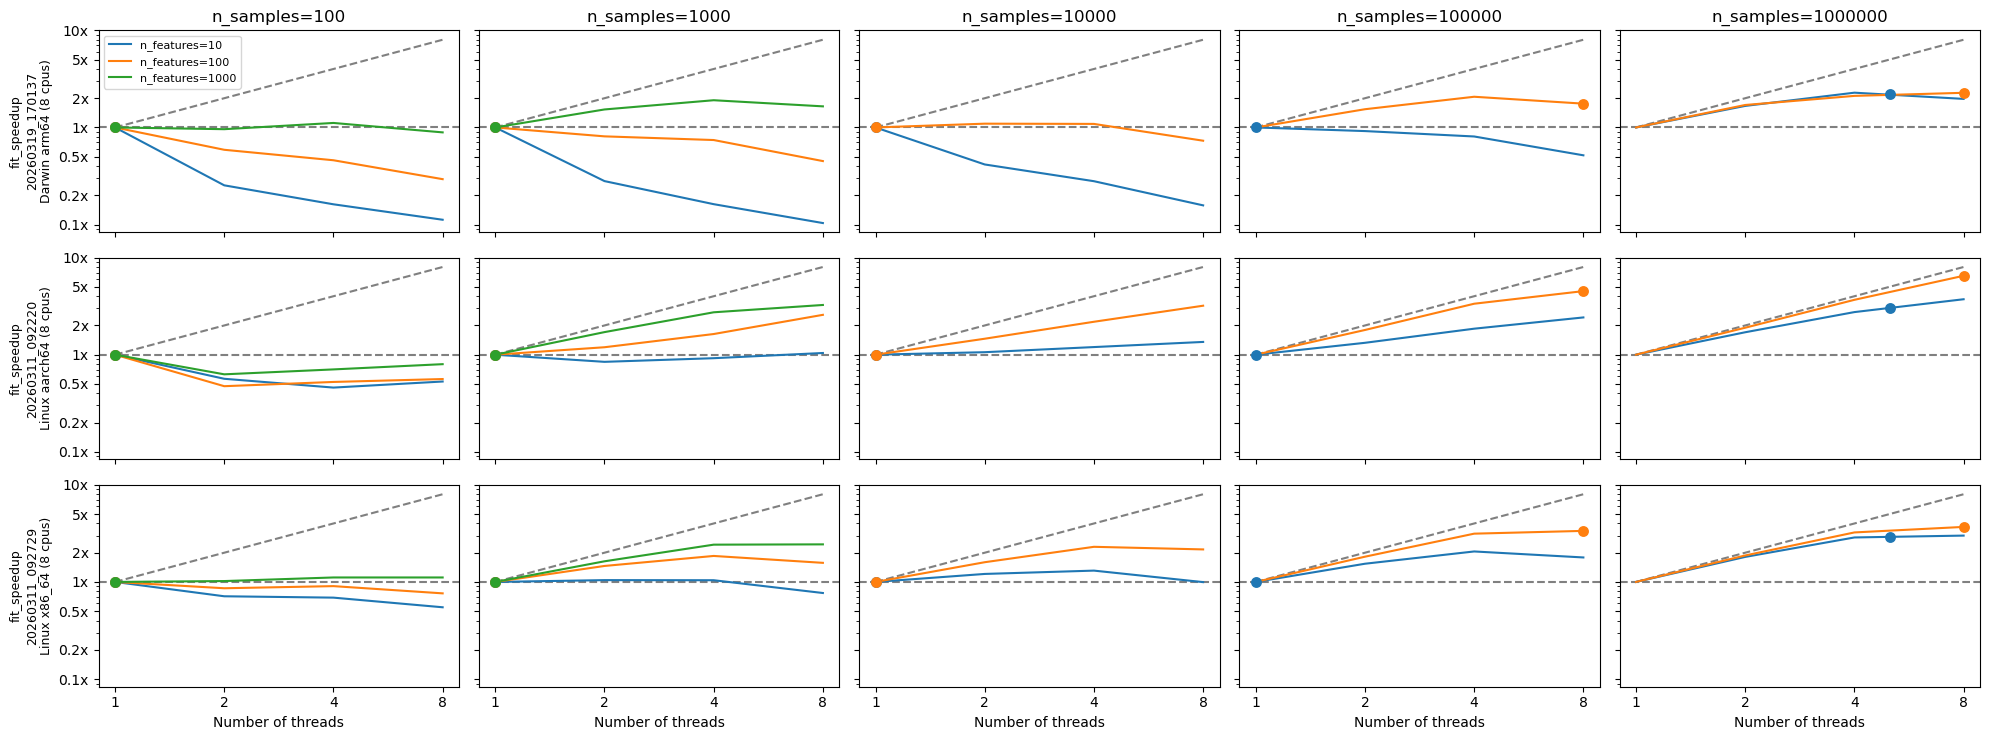

In [5]:
plot_fit_speedup_grid(results_df.query("n_cpus==8"), get_n_threads_limited_32955, ycol="fit_speedup");

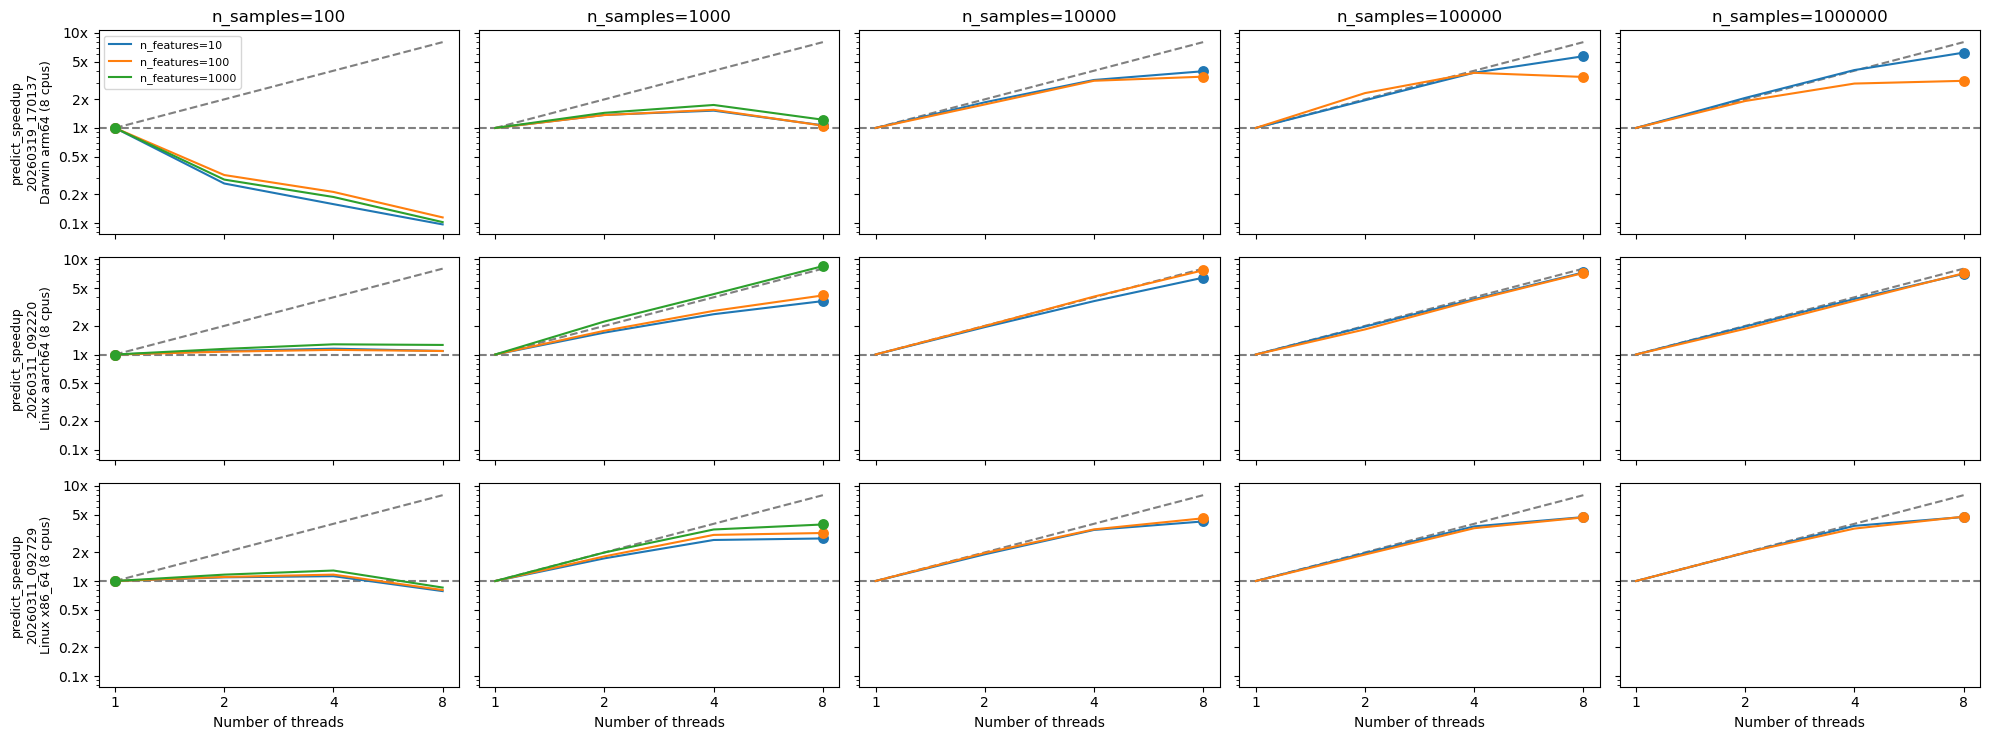

In [ ]:
def get_n_threads_limited_small_n(n_samples, n_features, n_cpus):
    # single threaded for small n_samples
    n_threads = 1 if (n_samples < 1000) else n_cpus
    return n_threads
plot_fit_speedup_grid(results_df.query("n_cpus==8"), get_n_threads_limited_small_n, ycol="predict_speedup");

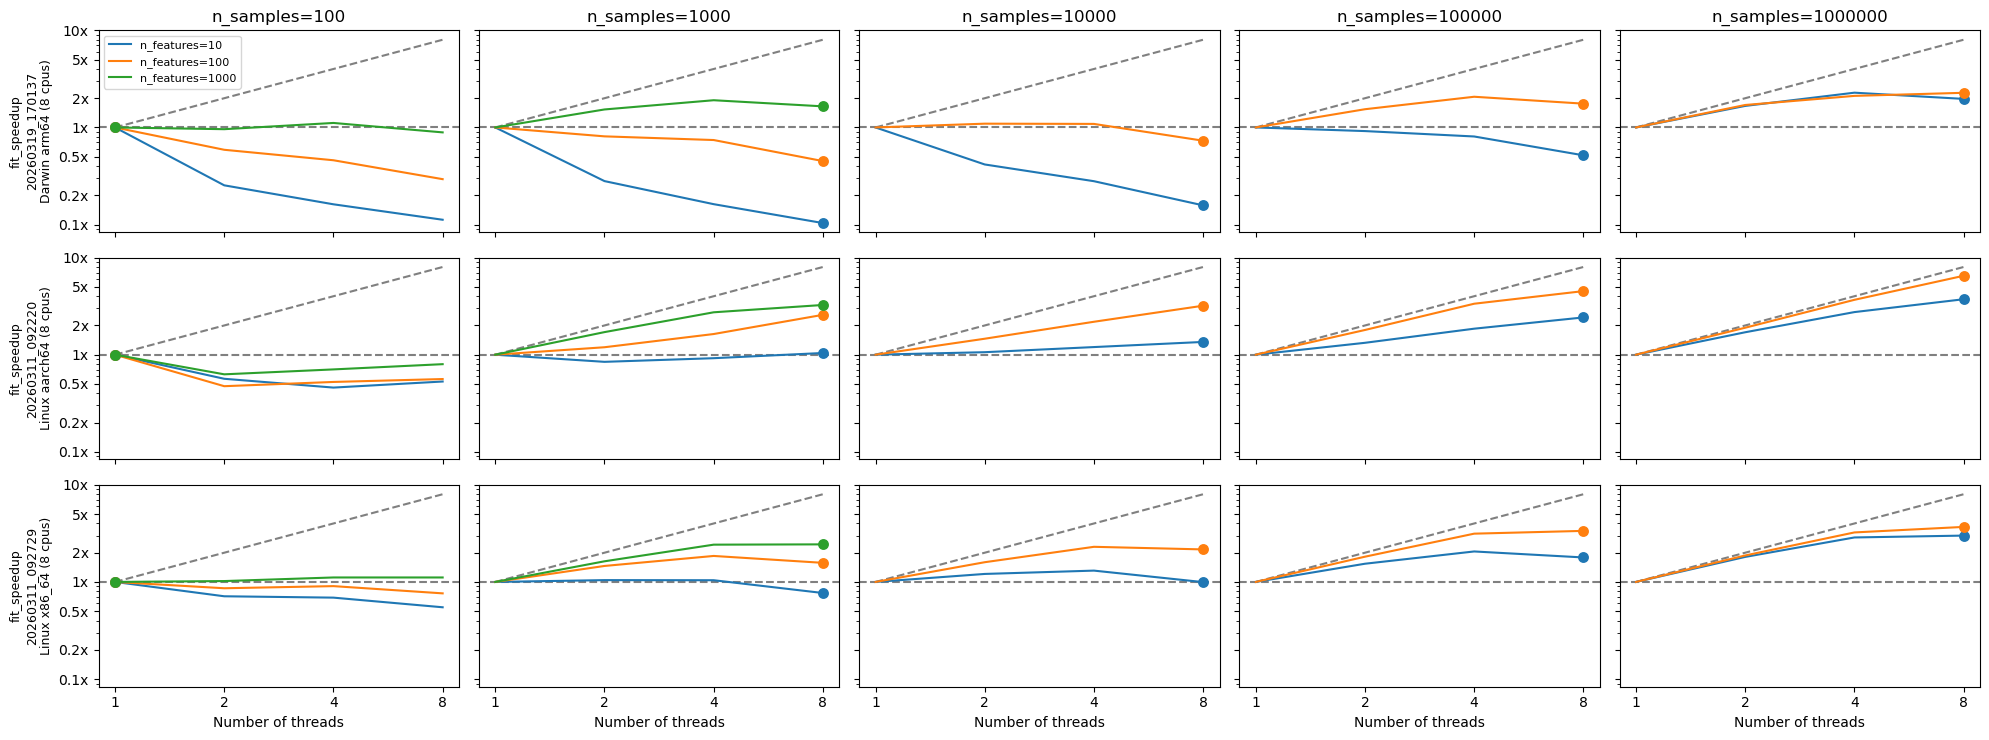

In [7]:
# FIXME: need to find the good combination of n_samples, n_features
plot_fit_speedup_grid(results_df.query("n_cpus==8"), get_n_threads_limited_small_n, ycol="fit_speedup");